# Customer Churn: Modeling

This notebook is part of a multi-notebook customer churn project.

The goal of this notebook is to build machine learning models that predict whether a customer is likely to churn. The previous notebooks cleaned the dataset, explored churn patterns, and identified high-risk customer segments.


## Project Notebooks

1. **Customer Churn: EDA**  
   Cleans the dataset, creates churn-related features, and explores major churn patterns.

2. **Customer Churn: Insights**  
   Builds customer segments and identifies high-risk churn groups.

3. **Customer Churn: Modeling**  
   Trains machine learning models to predict customer churn.

4. **Customer Churn: Recommendations**  
   Interprets segment and model results and turns findings into retention recommendations.


## Notebook Goals

In this notebook, we will:

- Load the cleaned churn dataset
- Prepare features for machine learning
- Split the data into training and testing sets
- Build a baseline model
- Train classification models
- Compare model performance using accuracy, precision, recall, F1-score, and ROC-AUC
- Select a final churn model and threshold


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
import os

if os.path.exists("/kaggle/input"):
    for dirname, _, filenames in os.walk("/kaggle/input"):
        for filename in filenames:
            print(os.path.join(dirname, filename))
else:
    print("Not running on Kaggle; using local repository paths where available.")

/kaggle/input/notebooks/anav24/customer-churn-insights/customer_tenure_segments.csv
/kaggle/input/notebooks/anav24/customer-churn-insights/__results__.html
/kaggle/input/notebooks/anav24/customer-churn-insights/key_churn_segments.csv
/kaggle/input/notebooks/anav24/customer-churn-insights/support_segments.csv
/kaggle/input/notebooks/anav24/customer-churn-insights/__notebook__.ipynb
/kaggle/input/notebooks/anav24/customer-churn-insights/__output__.json
/kaggle/input/notebooks/anav24/customer-churn-insights/contract_tenure_segments.csv
/kaggle/input/notebooks/anav24/customer-churn-insights/internet_payment_segments.csv
/kaggle/input/notebooks/anav24/customer-churn-insights/risk_factor_summary.csv
/kaggle/input/notebooks/anav24/customer-churn-insights/custom.css
/kaggle/input/notebooks/anav24/customer-churn-insights/__results___files/__results___22_0.png
/kaggle/input/notebooks/anav24/customer-churn-insights/__results___files/__results___12_0.png
/kaggle/input/notebooks/anav24/customer-chu

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

kaggle_path = Path("/kaggle/input/notebooks/anav24/customer-churn-eda/telco_churn_cleaned.csv")
local_path = PROJECT_ROOT / "outputs" / "telco_churn_cleaned.csv"

if kaggle_path.exists():
    file_path = kaggle_path
elif local_path.exists():
    file_path = local_path
else:
    raise FileNotFoundError(
        "Cleaned dataset not found. Run customer-churn-eda.ipynb first, "
        "or place telco_churn_cleaned.csv in the outputs/ folder."
    )

df = pd.read_csv(file_path)

print("Loaded from:", file_path)
print("Shape:", df.shape)
df.head()

Shape: (7043, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,Tenure_Group,Risk_Factor_Count
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,3
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,5


In [4]:
target = "Churn_Flag"

drop_cols = [
    "customerID",
    "Churn",
    "Churn_Flag",
    "Tenure_Group",
    "Risk_Factor_Count"
]

X = df.drop(columns=drop_cols)
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True))

Feature shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn_Flag
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [5]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining churn rate:", f"{y_train.mean():.2%}")
print("Testing churn rate:", f"{y_test.mean():.2%}")

Training shape: (5634, 19)
Testing shape: (1409, 19)

Training churn rate: 26.54%
Testing churn rate: 26.54%


In [7]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Preprocessing Pipeline

The dataset includes both numeric and categorical features. Numeric features are scaled, and categorical features are one-hot encoded so they can be used by machine learning models.

In [8]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Model Evaluation Helper

This helper function trains a model, makes predictions, and stores the main classification metrics.

Because churn prediction is focused on finding customers likely to leave, recall and F1-score are especially important. Accuracy alone can be misleading because most customers did not churn.

In [9]:
model_results = []

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc
    }
    
    model_results.append(results)
    
    print(model_name)
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return model

## Baseline Model

The baseline model predicts the most common class. Since most customers did not churn, this model will predict every customer as "No Churn."

This gives us a simple benchmark. A useful churn model should perform better than this baseline, especially for recall and F1-score.

In [10]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy_model = evaluate_model(
    "Dummy Baseline",
    dummy_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Dummy Baseline
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



In [11]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

log_reg_model = evaluate_model(
    "Logistic Regression",
    log_reg_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Baseline vs Logistic Regression Findings

The dummy baseline achieved 73% accuracy by predicting every customer as "No Churn." However, it completely failed to identify churned customers, with 0.00 recall and 0.00 F1-score for the churn class.

Logistic Regression performed much better for churn prediction. It identified 78% of churned customers, giving it a churn recall of 0.78 and a churn F1-score of 0.61.

Although Logistic Regression has lower precision for churn than for non-churn, it is much more useful than the baseline because it can actually detect customers who are likely to leave.

## Random Forest

Random Forest is an ensemble model that combines many decision trees. It can capture more complex relationships between customer features and churn than Logistic Regression.

In [12]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model = evaluate_model(
    "Random Forest",
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



## Gradient Boosting

Gradient Boosting is another ensemble model. It builds decision trees sequentially, with each new tree trying to improve on the errors made by the previous trees.

In [13]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_model = evaluate_model(
    "Gradient Boosting",
    gb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [14]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values("F1", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841639
3,Gradient Boosting,0.802697,0.665517,0.516043,0.581325,0.843366
2,Random Forest,0.782825,0.618881,0.473262,0.536364,0.823214
0,Dummy Baseline,0.734564,0.000000,0.000000,0.000000,0.500000


## Model Comparison Findings

The models show different tradeoffs.

The dummy baseline achieved 73.46% accuracy, but it did not identify any churned customers. This shows why accuracy alone is not enough for churn prediction.

Logistic Regression had the best churn recall at 0.78 and the best F1-score at 0.61. This means it was the strongest model for identifying customers likely to churn.

Gradient Boosting had the highest accuracy at 80.27% and the highest ROC-AUC at 0.843, but its churn recall was lower at 0.52. This means it was more conservative and missed more churned customers than Logistic Regression.

For a churn retention problem, recall is especially important because the business wants to identify customers before they leave. Based on the current results, Logistic Regression is the best model for churn detection.

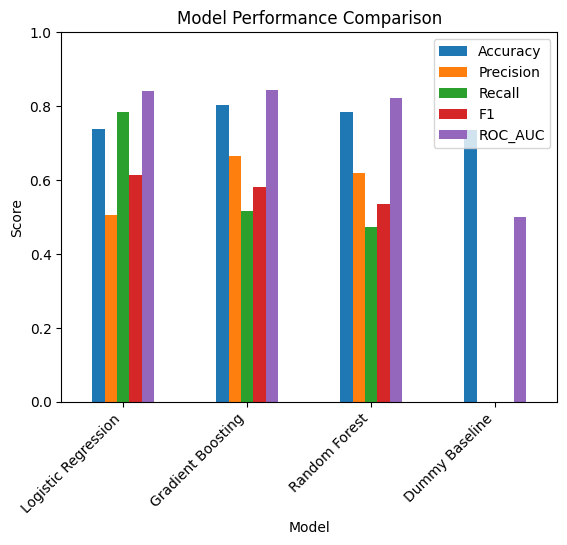

In [15]:
results_df.plot(
    kind="bar",
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

## Confusion Matrices

Confusion matrices show how many customers were correctly or incorrectly classified.

For churn prediction, the most important mistake is a false negative: a customer who actually churned but the model predicted as not churned.

In [16]:
def plot_confusion_matrix(model, model_name):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

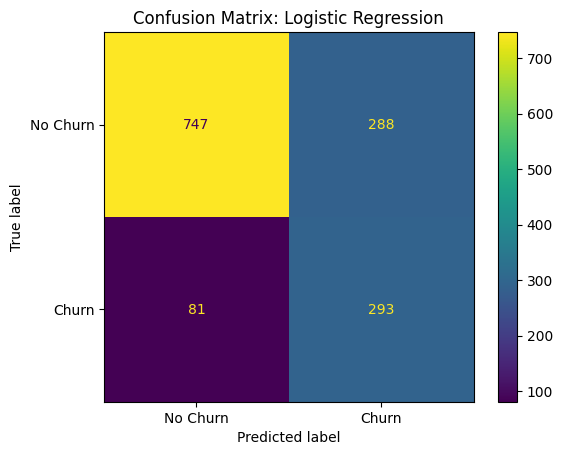

In [17]:
plot_confusion_matrix(log_reg_model, "Logistic Regression")

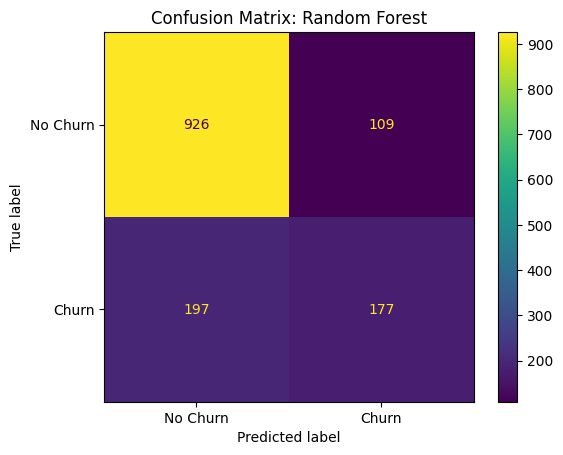

In [18]:
plot_confusion_matrix(rf_model, "Random Forest")

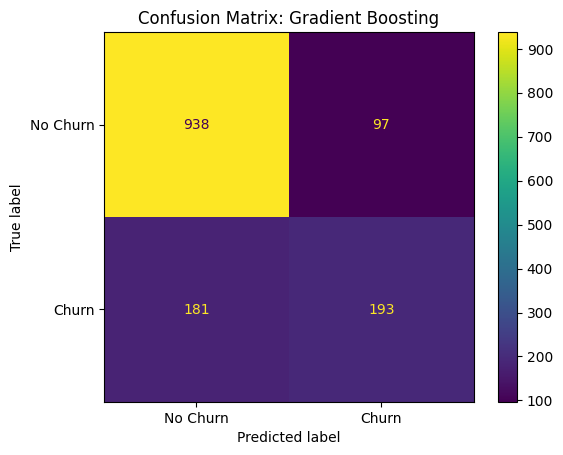

In [19]:
plot_confusion_matrix(gb_model, "Gradient Boosting")

In [20]:
for model_name, model in [
    ("Logistic Regression", log_reg_model),
    ("Random Forest", rf_model),
    ("Gradient Boosting", gb_model)
]:
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(model_name)
    print(cm)
    print()

Logistic Regression
[[747 288]
 [ 81 293]]

Random Forest
[[926 109]
 [197 177]]

Gradient Boosting
[[938  97]
 [181 193]]



## Confusion Matrix Findings

The confusion matrices show that Logistic Regression is the best model for identifying churned customers.

Logistic Regression correctly identified 293 churned customers and missed 81 churned customers. Random Forest and Gradient Boosting had fewer false churn alarms, but they missed many more churned customers.

For a churn retention problem, missed churners are especially important because those are customers the business would fail to target before they leave. Based on this tradeoff, Logistic Regression remains the strongest model for churn detection.

## Logistic Regression Threshold Tuning

By default, classification models usually use a probability threshold of 0.50. If a customer's predicted churn probability is at least 0.50, the model predicts churn.

For churn prediction, the business may want to lower or raise this threshold depending on the goal:

- A lower threshold catches more churned customers but creates more false alarms.
- A higher threshold creates fewer false alarms but misses more churned customers.

This section compares Logistic Regression performance across several thresholds.

In [21]:
log_reg_proba = log_reg_model.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    y_pred_threshold = (log_reg_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.654365,0.429988,0.927807,0.587638
1,0.35,0.677786,0.447090,0.903743,0.598230
2,0.40,0.701207,0.466187,0.866310,0.606174
3,0.45,0.718240,0.482280,0.836898,0.611926
4,0.50,0.738112,0.504303,0.783422,0.613613
5,0.55,0.753016,0.524254,0.751337,0.617582
6,0.60,0.762243,0.539877,0.705882,0.611819
7,0.65,0.777147,0.568182,0.668449,0.614251
8,0.70,0.788502,0.601604,0.601604,0.601604


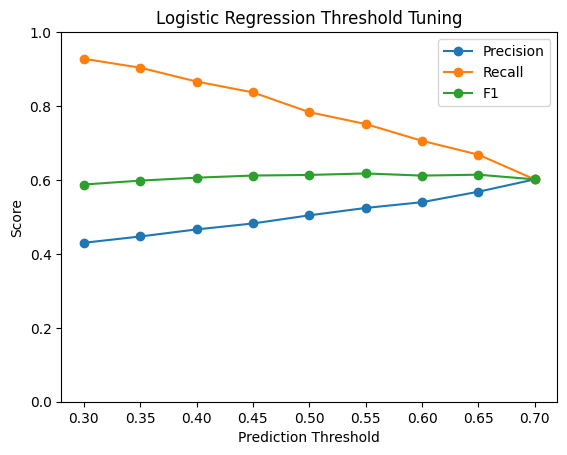

In [22]:
threshold_df.plot(
    kind="line",
    x="Threshold",
    y=["Precision", "Recall", "F1"],
    marker="o"
)

plt.title("Logistic Regression Threshold Tuning")
plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

In [23]:
best_threshold_row = threshold_df.sort_values("F1", ascending=False).head(1)

best_threshold_row

,Threshold,Accuracy,Precision,Recall,F1
5,0.55,0.753016,0.524254,0.751337,0.617582


## Threshold Tuning Findings

The default Logistic Regression threshold of 0.50 performed well, with an F1-score of 0.614 and recall of 0.783.

After testing multiple thresholds, the best F1-score occurred at a threshold of 0.55. At this threshold, the model achieved:

- Accuracy: 75.30%
- Precision: 52.43%
- Recall: 75.13%
- F1-score: 61.76%

This threshold slightly improves the balance between precision and recall compared with the default 0.50 threshold. Because churn prediction needs to identify likely churners while avoiding too many false alarms, Logistic Regression with a 0.55 threshold is selected as the final model for this notebook.

In [24]:
final_threshold = 0.55

final_y_pred = (log_reg_proba >= final_threshold).astype(int)

print("Final Model: Logistic Regression")
print("Selected threshold:", final_threshold)
print()
print(classification_report(y_test, final_y_pred, zero_division=0))

Final Model: Logistic Regression
Selected threshold: 0.55

              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



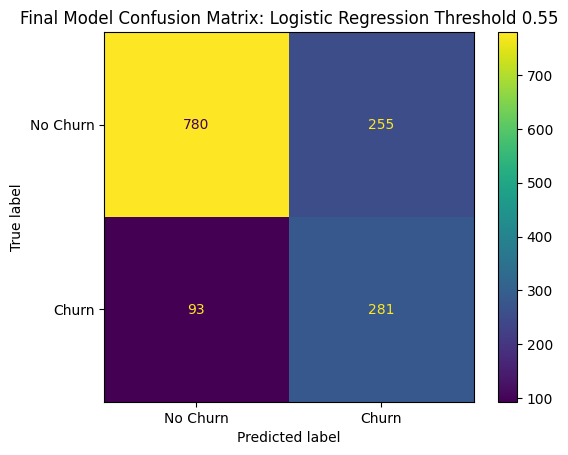

array([[780, 255],
       [ 93, 281]])

In [25]:
final_cm = confusion_matrix(y_test, final_y_pred)

final_disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Churn", "Churn"]
)

final_disp.plot()
plt.title("Final Model Confusion Matrix: Logistic Regression Threshold 0.55")
plt.show()

final_cm

In [26]:
final_model_summary = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Threshold": [final_threshold],
    "Accuracy": [accuracy_score(y_test, final_y_pred)],
    "Precision": [precision_score(y_test, final_y_pred, zero_division=0)],
    "Recall": [recall_score(y_test, final_y_pred, zero_division=0)],
    "F1": [f1_score(y_test, final_y_pred, zero_division=0)],
    "ROC_AUC": [roc_auc_score(y_test, log_reg_proba)]
})

final_model_summary

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.55,0.753016,0.524254,0.751337,0.617582,0.841639


## Final Model Summary

The final selected model is Logistic Regression with a threshold of 0.55.

This model achieved a recall of 75.13%, meaning it identified about three out of every four churned customers in the test set. Its F1-score of 61.76% was the best result from the threshold tuning process.

Although Gradient Boosting had slightly higher accuracy and ROC-AUC, Logistic Regression was selected because churn prediction is focused on identifying customers at risk of leaving. In this context, recall and F1-score are more important than accuracy alone.

## Modeling Conclusion

This notebook trained and compared several machine learning models for customer churn prediction.

The dummy baseline achieved 73.46% accuracy but failed to identify any churned customers. This confirmed that accuracy alone is not enough for this problem.

Logistic Regression, Random Forest, and Gradient Boosting all improved on the baseline. Gradient Boosting had the highest overall accuracy and ROC-AUC, but Logistic Regression performed best for churn detection because it had the highest recall and F1-score.

After threshold tuning, Logistic Regression with a 0.55 threshold was selected as the final model. This model achieved the best F1-score while still identifying about 75% of churned customers.

The next notebook will interpret the final model and connect the model results back to business recommendations.

In [27]:
from pathlib import Path

output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else PROJECT_ROOT / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "model_comparison_results.csv", index=False)
threshold_df.to_csv(output_dir / "logistic_regression_threshold_results.csv", index=False)
final_model_summary.to_csv(output_dir / "final_model_summary.csv", index=False)

print(f"Notebook 3 modeling outputs saved to {output_dir}")

Notebook 3 modeling outputs saved.
